In [1]:
from pyspark.sql import SparkSession

from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler
)

from pyspark.ml import Pipeline

from pyspark.ml.classification import RandomForestClassifier

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator
)

from pyspark.ml.tuning import (
    ParamGridBuilder,
    CrossValidator
)

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#tes
spark = SparkSession.builder \
    .appName("EmployeeAttritionML") \
    .config(
        "spark.jars.packages",
        "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262"
    ) \
    .config("spark.hadoop.fs.s3a.endpoint", "http://bda-minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

In [5]:
df = spark.read.parquet(
    "s3a://datalake/silver/employee-attrition/"
)

In [8]:
df.printSchema()
print("Jumlah data:", df.count())

root
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Years at Company: integer (nullable = true)
 |-- Job Role: string (nullable = true)
 |-- Monthly Income: integer (nullable = true)
 |-- Work-Life Balance: string (nullable = true)
 |-- Job Satisfaction: string (nullable = true)
 |-- Performance Rating: string (nullable = true)
 |-- Number of Promotions: integer (nullable = true)
 |-- Overtime: string (nullable = true)
 |-- Distance from Home: integer (nullable = true)
 |-- Education Level: string (nullable = true)
 |-- Marital Status: string (nullable = true)
 |-- Number of Dependents: integer (nullable = true)
 |-- Job Level: string (nullable = true)
 |-- Company Size: string (nullable = true)
 |-- Company Tenure: integer (nullable = true)
 |-- Remote Work: string (nullable = true)
 |-- Leadership Opportunities: string (nullable = true)
 |-- Innovation Opportunities: string (nullable = true)
 |-- Company Reputation: string (nullable = true)
 |-- Employ

In [9]:
ignore_cols = ["Employee ID", "Attrition"]

cat_cols = [
    f.name for f in df.schema.fields
    if f.dataType.typeName() == "string"
    and f.name not in ignore_cols
]

num_cols = [
    f.name for f in df.schema.fields
    if f.dataType.typeName() in ["integer", "double"]
    and f.name not in ignore_cols
]

In [10]:
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in cat_cols
]

In [11]:
label_indexer = StringIndexer(
    inputCol="Attrition",
    outputCol="label"
)

In [12]:
encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cat_cols],
    outputCols=[f"{c}_ohe" for c in cat_cols],
    dropLast=True
)

In [13]:
assembler_inputs = (
    num_cols +
    [f"{c}_ohe" for c in cat_cols]
)

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features"
)

In [14]:
pipeline = Pipeline(
    stages=indexers + [
        label_indexer,
        encoder,
        assembler
    ]
)

In [15]:
fe_model = pipeline.fit(df)

In [16]:
df_encoded = fe_model.transform(df)

In [18]:
gold_df = df_encoded.select(
    "features",
    "label"
)

In [19]:
train_split, test_split = gold_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [21]:
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=100,
    maxDepth=12,
    seed=42
)

In [22]:
rf_model = rf.fit(train_split)

In [23]:
predictions = rf_model.transform(test_split)

In [24]:
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

In [25]:
accuracy = accuracy_eval.evaluate(predictions)
f1 = f1_eval.evaluate(predictions)
precision = precision_eval.evaluate(predictions)
recall = recall_eval.evaluate(predictions)

print("Accuracy :", accuracy)
print("F1 Score :", f1)
print("Precision :", precision)
print("Recall :", recall)

Accuracy : 0.7471117906897723
F1 Score : 0.7470265609466951
Precision : 0.747002072982887
Recall : 0.7471117906897724


In [26]:
## hyper parameter turning
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50])
    .addGrid(rf.maxDepth, [5, 8])
    .build()
)

In [27]:
cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=f1_eval,
    numFolds=3
)

In [28]:
cv_model = cv.fit(train_split)

In [29]:
best_model = cv_model.bestModel

In [30]:
best_predictions = best_model.transform(test_split)

In [31]:
best_accuracy = accuracy_eval.evaluate(best_predictions)
best_f1 = f1_eval.evaluate(best_predictions)
best_precision = precision_eval.evaluate(best_predictions)
best_recall = recall_eval.evaluate(best_predictions)

In [32]:
best_accuracy = accuracy_eval.evaluate(best_predictions)
best_f1 = f1_eval.evaluate(best_predictions)
best_precision = precision_eval.evaluate(best_predictions)
best_recall = recall_eval.evaluate(best_predictions)

print(" BEST MODEL RESULT ")
print("Accuracy :", best_accuracy)
print("F1 Score :", best_f1)
print("Precision:", best_precision)
print("Recall   :", best_recall)

 BEST MODEL RESULT 
Accuracy : 0.7334352701325179
F1 Score : 0.7332304697687332
Precision: 0.7332708080696693
Recall   : 0.7334352701325179


In [33]:
## feature Importance
importance = best_model.featureImportances.toArray()

In [36]:
feature_names = []

# Tambahkan numeric columns
feature_names.extend(num_cols)

# Ambil nama hasil OHE
ohe_model = fe_model.stages[-2]

for i, col in enumerate(cat_cols):

    category_size = ohe_model.categorySizes[i]

    # karena dropLast=True
    for j in range(category_size - 1):

        feature_names.append(
            f"{col}_{j}"
        )

In [43]:
importance_df = (
    importance_df
    .groupby("Feature", as_index=False)
    ["Importance"]
    .sum()
)

In [38]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [44]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [42]:
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.split("_")
    .str[0]
)

In [47]:
top_features = importance_df.head(10)

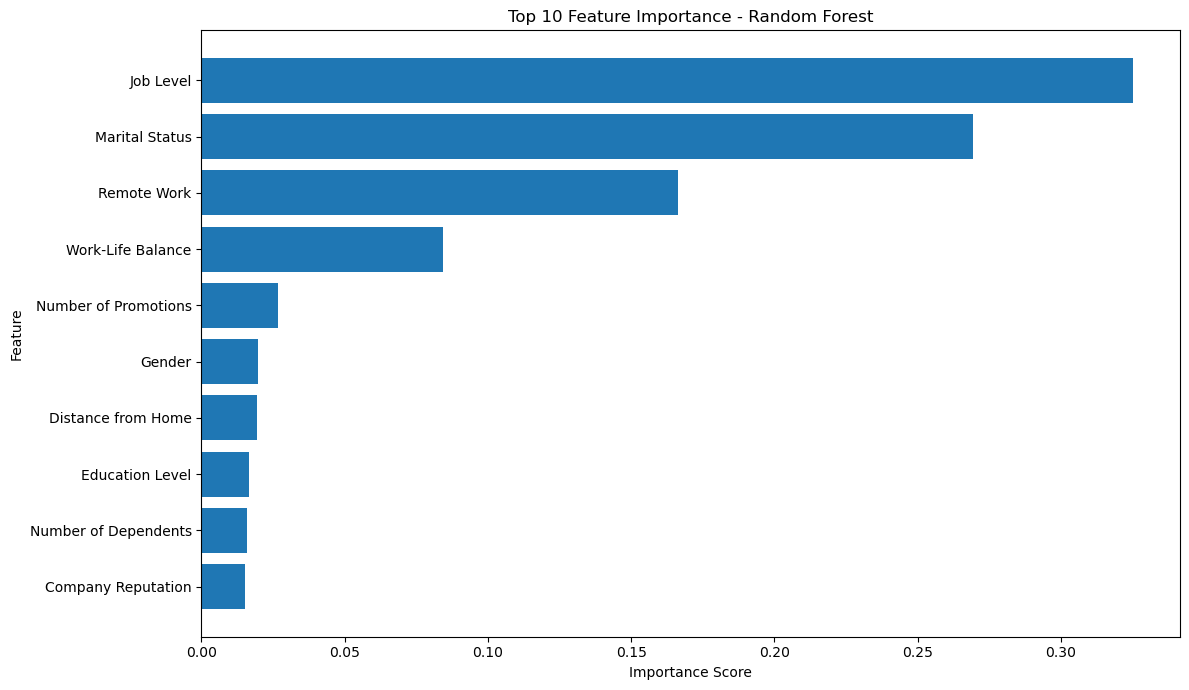

In [48]:
plt.figure(figsize=(12,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
from IPython.display import display

display(top_features)

,Feature,Importance
9,Job Level,0.325314
13,Marital Status,0.269310
19,Remote Work,0.166444
20,Work-Life Balance,0.084288
16,Number of Promotions,0.026881
7,Gender,0.019906
4,Distance from Home,0.019358
5,Education Level,0.016691
15,Number of Dependents,0.015907
1,Company Reputation,0.015118


In [50]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

spark.createDataFrame(importance_df).write \
    .mode("overwrite") \
    .parquet(
        "s3a://datalake/gold/feature_importance/"
    )

In [51]:
predictions.select(
    "label",
    "prediction"
).write.mode("overwrite").parquet(
    "s3a://datalake/gold/predictions/"
)

evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1 Score",
        "Precision",
        "Recall"
    ],
    "Value": [
        accuracy,
        f1,
        precision,
        recall
    ]
})

spark.createDataFrame(evaluation_df).write \
    .mode("overwrite") \
    .parquet(
        "s3a://datalake/gold/model_evaluation/"
    )

In [52]:
best_model.write().overwrite().save(
    "s3a://datalake/model/random_forest_model"
)